Question 3 - Use the stent image and apply the following operations
a. Enhance image
b. Add original image with a response of LoG filter and then enhance
c. Create a blurred version of the image with a 3-by-3 filter. Subtract the original from the
blurred version. Add the difference to the original image. Report the results

In [12]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def load_grayscale(path):
    """Load image as float64 grayscale in [0, 1]."""
    img = Image.open(path).convert("L")  # "L" = grayscale
    return np.asarray(img, dtype=np.float64) / 255.0

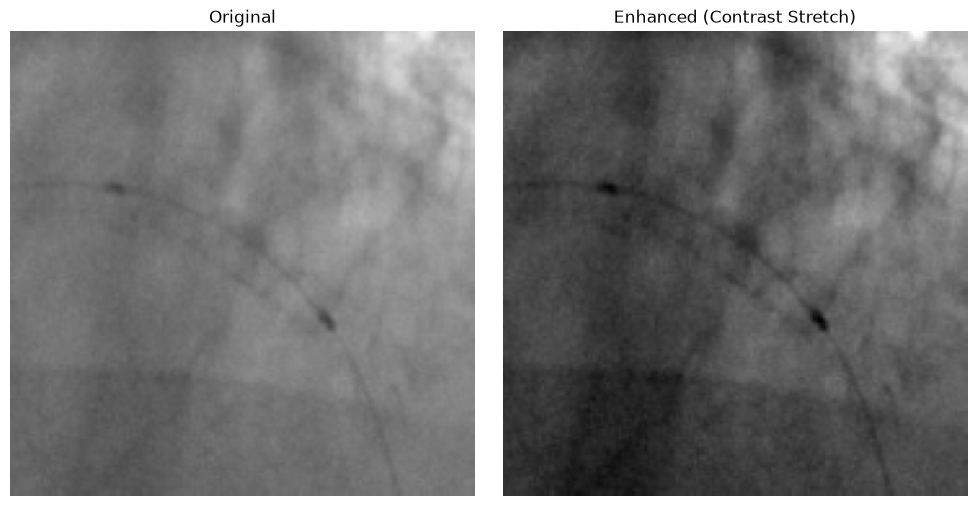

Original range:  [0.263, 0.945]
Enhanced range:  [0.000, 1.000]


In [14]:
def enhance_contrast(img):
    """
    Rescale pixel values so the darkest
    becomes 0 and the brightest becomes 1.
    """
    lo, hi = img.min(), img.max()
    if hi - lo < 1e-8:
        return img.copy()
    return (img - lo) / (hi - lo)

# Apply
img = load_grayscale("Stent_image.tif")
img_enhanced = enhance_contrast(img)

# Show
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original")
axes[1].imshow(img_enhanced, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Enhanced (Contrast Stretch)")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Report the change
print(f"Original range:  [{img.min():.3f}, {img.max():.3f}]")
print(f"Enhanced range:  [{img_enhanced.min():.3f}, {img_enhanced.max():.3f}]")

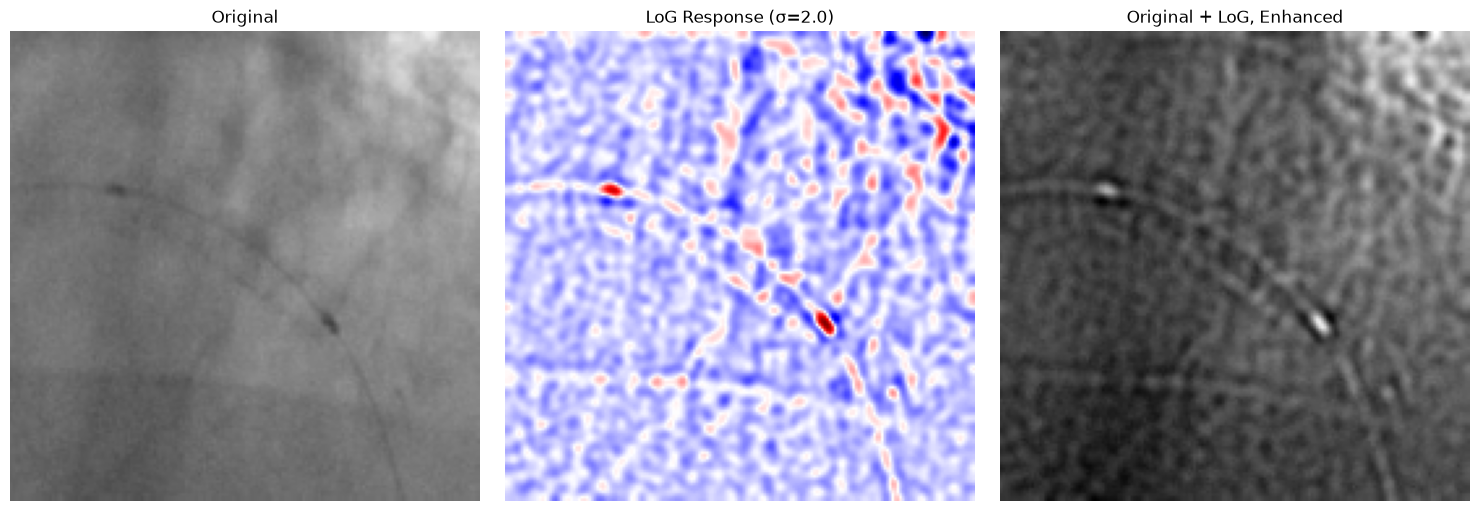

In [15]:
# 3b) Add Original + LoG Response, Then Enhance
def make_gaussian_2d(sigma, size=None):
    """2D Gaussian kernel."""
    if size is None:
        size = int(6 * sigma) | 1  # ensure odd
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return g / g.sum()

def make_log_2d(sigma, size=None):
    """2D Laplacian of Gaussian kernel."""
    if size is None:
        size = int(6 * sigma) | 1
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    r2 = xx**2 + yy**2
    # LoG formula
    log = ((r2 - 2 * sigma**2) / (sigma**4)) * np.exp(-r2 / (2 * sigma**2))
    # Zero-mean the kernel
    log -= log.mean()
    return log

def convolve2d_same(image, kernel):
    """2D convolution with 'same' output size (manual, no scipy)."""
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i+image.shape[0], j:j+image.shape[1]]
    return out

# Apply LoG
sigma = 2.0
LoG_kernel = make_log_2d(sigma)
LoG_response = convolve2d_same(img, LoG_kernel)

# Add original + LoG, then enhance
img_b = img + LoG_response
img_b_enhanced = enhance_contrast(img_b)

# Show
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1); axes[0].set_title("Original")
axes[1].imshow(LoG_response, cmap='seismic'); axes[1].set_title(f"LoG Response (σ={sigma})")
axes[2].imshow(img_b_enhanced, cmap='gray', vmin=0, vmax=1); axes[2].set_title("Original + LoG, Enhanced")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

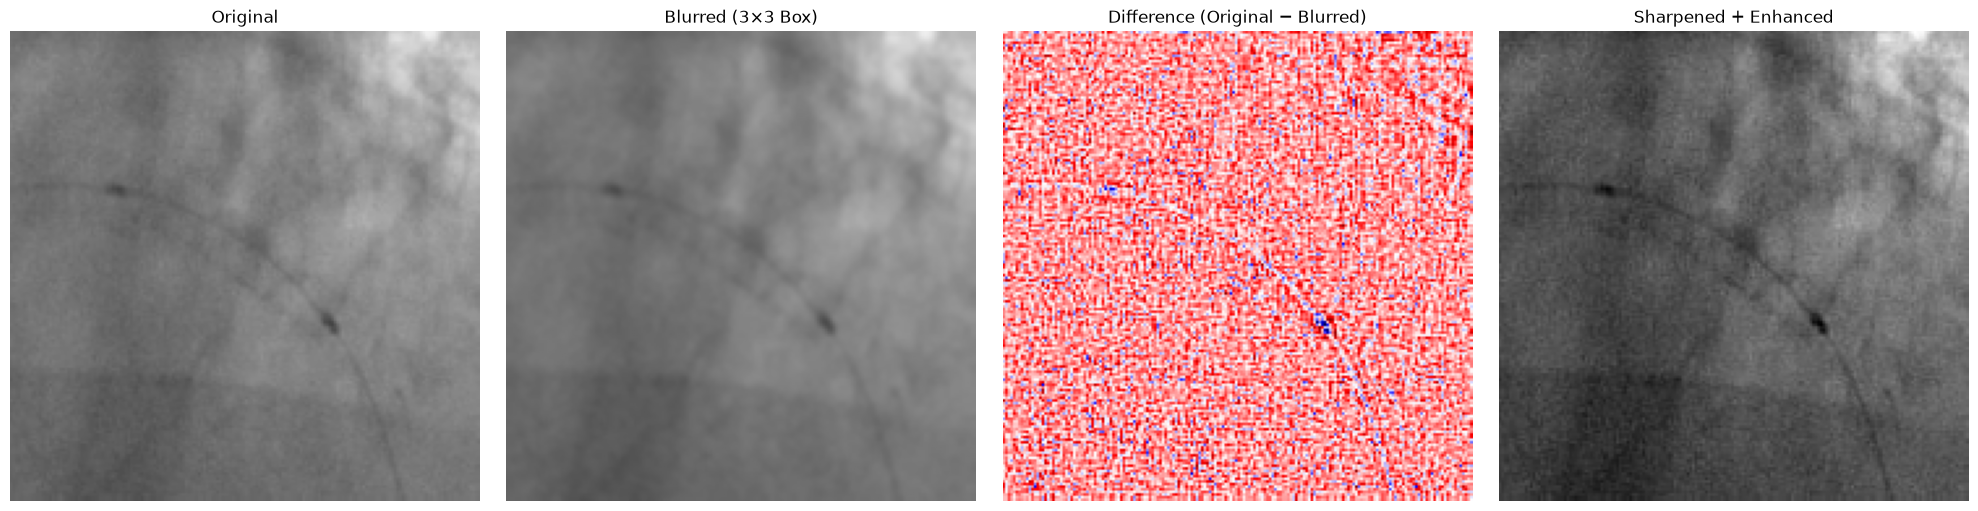

In [16]:
# 3c) Original + Detail, Then Enhance
# 3x3 box blur kernel
blur_kernel = np.ones((3, 3)) / 9.0

# Blur the original
img_blurred = convolve2d_same(img, blur_kernel)

# Compute difference and add back
img_detail = img - img_blurred
img_c = img + img_detail
img_c_enhanced = enhance_contrast(img_c)

# Show everything
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1); axes[0].set_title("Original")
axes[1].imshow(img_blurred, cmap='gray', vmin=0, vmax=1); axes[1].set_title("Blurred (3×3 Box)")
axes[2].imshow(img_detail, cmap='seismic'); axes[2].set_title("Difference (Original − Blurred)")
axes[3].imshow(img_c_enhanced, cmap='gray', vmin=0, vmax=1); axes[3].set_title("Sharpened + Enhanced")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()